In [1]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
import os
import xml.etree.ElementTree as ET
from PIL import Image
from torch.utils.data import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import random
import numpy as np
import matplotlib.patches as patches
import torchvision.transforms as T

In [10]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_EPOCHS = 20
BATCH_SIZE = 4
LR = 0.0005

train_path = r"D:\xu_li_anh\btl\train"
test_path  = r"D:\xu_li_anh\btl\valid"

In [12]:

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),      # Lật ngang ảnh (rất quan trọng với ảnh da liễu)
    T.RandomVerticalFlip(p=0.5),        # Lật dọc ảnh
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Chỉnh sáng/tương phản nhẹ
    T.ToTensor(),                       # Chuyển về Tensor [0, 1]
    T.Normalize(                        
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# đổi đường dẫn
# train_dataset = SkinCancerVOCDataset(train_path, transform=train_transform)
# test_dataset  = SkinCancerVOCDataset(test_path, transform=test_transform)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn,       
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=1,            
    shuffle=False, 
    collate_fn=collate_fn,
)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\xu_li_anh\\btl\\train'

In [ ]:
num_classes = len(train_dataset.class_to_idx) + 1  # + background

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# replace head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)
for param in model.backbone.parameters():
    param.requires_grad = False
model.to(DEVICE)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
print(num_classes)

9


In [ ]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total parameters     : {total_params:,}")
    print(f"Trainable parameters : {trainable_params:,}")
    print(f"Frozen parameters    : {total_params - trainable_params:,}")

In [ ]:
count_parameters(model)

Total parameters     : 41,335,036
Trainable parameters : 14,535,740
Frozen parameters    : 26,799,296


In [ ]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(params,
                            lr=LR, 
                            weight_decay=0.003)

In [ ]:
train_losses = []
val_losses = []

best_loss = float("inf")

os.makedirs("checkpoints", exist_ok=True)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")

    for images, targets in train_bar:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
        loss_dict = model(images, targets)
        losses = torch.stack(list(loss_dict.values())).sum()
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
        train_bar.set_postfix(loss=losses.item())

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    val_loss = 0
    model.eval() 
    with torch.no_grad():
        for images, targets in test_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            v_losses = torch.stack(list(loss_dict.values())).sum()
            val_loss += v_losses.item()
    
    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    
    # In kết quả sau mỗi Epoch
    print(f"\n=> Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
    # Lưu Checkpoint
    torch.save(model.state_dict(), "checkpoints/last.pth")
    
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), "checkpoints/best.pth")
        print("--- Saved BEST model ---")

Epoch 1/20 [Train]:  12%|█▏        | 126/1014 [01:22<09:43,  1.52it/s, loss=0.282]


AssertionError: All bounding boxes should have positive height and width. Found invalid box [93.75, 142.5, 98.75, 142.5] for target at index 1.

In [ ]:
for k, v in loss_dict.items():
    print(k, v.item())

loss_classifier 0.1392107456922531
loss_box_reg 0.11355002224445343
loss_objectness 0.02389695681631565
loss_rpn_box_reg 0.005835565272718668


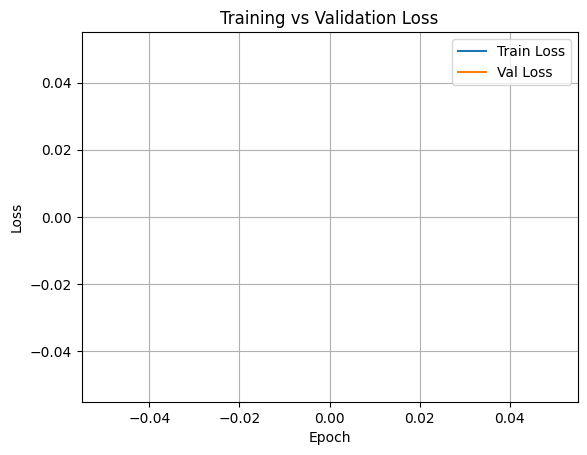

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.savefig("loss_curve.png")
plt.show()

# Test

In [ ]:
import torchvision.ops as ops
import torch

def visualize_prediction(image, output, idx_to_class=None, conf_threshold=0.5, iou_threshold=0.3):
    # 1. Chuyển tensor sang CPU để xử lý
    boxes = output["boxes"].cpu()
    labels = output["labels"].cpu()
    scores = output["scores"].cpu()

    # 2. Áp dụng NMS để loại bỏ các box chồng lấp 
    keep_idx = ops.nms(boxes, scores, iou_threshold)
    
    boxes = boxes[keep_idx]
    labels = labels[keep_idx]
    scores = scores[keep_idx]

    # 3. Bắt đầu vẽ
    image_np = image.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image_np)

    for box, label, score in zip(boxes, labels, scores):
        # Lọc theo độ tự tin mới (ví dụ 0.5)
        if score < conf_threshold:
            continue
        
        xmin, ymin, xmax, ymax = box.numpy()
        
        # Vẽ rectangle
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Text label
        class_name = idx_to_class[label.item()] if idx_to_class else str(label.item())
        ax.text(xmin, ymin - 5, f"{class_name}: {score:.2f}",
                color='red', fontsize=10, backgroundcolor='white')

    plt.axis("off")
    plt.show()

In [ ]:
import torch
from PIL import Image
import torchvision.transforms as T


def predict_image(image_path, model, device, idx_to_class=None, score_thresh=0.5):
    transform = T.Compose([T.ToTensor()])
    
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model([image_tensor])[0]
    
    return image_tensor.cpu(), output

In [ ]:
image_path = r"D:\xu_li_anh\btl\Skin Cancer - ISIC-2019.v2i.voc\test\ISIC_0000021_downsampled_jpg.rf.8c49330bcfaf4afb3fd31b5b5f79ec11.jpg"

In [ ]:
# mapping label
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

image_tensor, output = predict_image(image_path, model, DEVICE)

visualize_prediction(image_tensor, output, idx_to_class)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\xu_li_anh\\btl\\Skin Cancer - ISIC-2019.v2i.voc\\test\\ISIC_0000021_downsampled_jpg.rf.8c49330bcfaf4afb3fd31b5b5f79ec11.jpg'